In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 106.8 MB/s eta 0:00:00


In [2]:
import os, re, time, random
from pathlib import Path
from collections import defaultdict, OrderedDict
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pennylane as qml
import torchvision.models as models
from torchvision.models import EfficientNet_B0_Weights
from torchvision import transforms
import cv2
import numpy as np
import time
import random
from copy import deepcopy

/usr/local/lib/python3.11/dist-packages/pennylane/__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


In [3]:
DATASET_ROOT = Path("/kaggle/input/BreaKHis_v1/BreaKHis_v1/histology_slides/breast")
IMG_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff"}
RANDOM_SEED = 42
SPLIT_RATIO = 0.8
BATCH_SIZE = 32
NUM_WORKERS = 2

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp'}
PAT_200 = re.compile(r"200x")
PAT_400 = re.compile(r"400x")

In [4]:
class CLAHETransform:
    def __init__(self, clip_limit=2.0, tile_grid_size=(8,8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, img):
        img = np.array(img)
        img = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(img)
        l2 = self.clahe.apply(l)
        img = cv2.merge([l2, a, b])
        img = cv2.cvtColor(img, cv2.COLOR_LAB2RGB)
        return Image.fromarray(img)

In [5]:
train_tf = transforms.Compose([
    CLAHETransform(),                     
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_tf = transforms.Compose([
    CLAHETransform(),             
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


In [ ]:
def list_all_images(root: Path):
    imgs = []
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            imgs.append(p)
    return imgs


def build_subclass_candidates(root: Path, main_class: str):
    base = root / main_class
    candidates = set()
    if not base.exists():
        return candidates

    for child in base.iterdir():
        if child.is_dir():
            candidates.add(child.name.lower())
            for grand in child.iterdir():
                if grand.is_dir():
                    candidates.add(grand.name.lower())
                    for g2 in grand.iterdir():
                        if g2.is_dir():
                            candidates.add(g2.name.lower())
    return candidates


def extract_subclass_from_path(path: Path, main_class: str, subclass_candidates: set):
    parts = list(path.parts)
    parts_low = [p.lower() for p in parts]

    try:
        main_idx = parts_low.index(main_class)
    except ValueError:
        return None

    # Direct match
    for p in parts_low[main_idx + 1 :]:
        if p in subclass_candidates:
            return p

    # Fallback heuristic 
    if main_idx + 1 < len(parts_low):
        return parts_low[main_idx + 1]

    return None



In [7]:
if not DATASET_ROOT.exists():
    raise FileNotFoundError(f"DATASET_ROOT not found: {DATASET_ROOT}")

sub_candidates = {
    "benign": build_subclass_candidates(DATASET_ROOT, "benign"),
    "malignant": build_subclass_candidates(DATASET_ROOT, "malignant"),
}

all_images = list_all_images(DATASET_ROOT)
print(f"Total images discovered (ALL magnifications): {len(all_images)}")

counters = {
    "benign": defaultdict(list),
    "malignant": defaultdict(list),
    "unknown": defaultdict(list),
}

for p in all_images:
    parts_low = [pp.lower() for pp in p.parts]

    if "benign" in parts_low:
        main = "benign"
    elif "malignant" in parts_low:
        main = "malignant"
    else:
        main = "unknown"

    subclass = extract_subclass_from_path(
        p, main, sub_candidates.get(main, set())
    )

    if subclass is None:
        subclass = "unknown_subclass"

    counters[main][subclass].append(str(p))


Total images discovered (ALL magnifications): 7909


In [ ]:
from collections import Counter
import re

print("\n=== Image counts per class / subclass (ALL magnifications) ===")
for main in counters:
    print(f"\nMAIN CLASS: {main.upper()}")
    for subclass, files in sorted(counters[main].items()):
        print(f"  {subclass:30s}  total={len(files):4d}")

filepaths = []
labels = []
label_names = []
label_map = {}

selected_subclasses = []
for main in ("benign", "malignant"):
    for subclass, files in counters[main].items():
        if len(files) > 0:
            selected_subclasses.append((main, subclass))

if not selected_subclasses:
    raise RuntimeError("No valid benign/malignant subclasses found.")

for idx, (main, subclass) in enumerate(sorted(selected_subclasses)):
    label_map[(main, subclass)] = idx
    label_names.append(f"{main}/{subclass}")

for (main, subclass), idx in label_map.items():
    for fp in counters[main][subclass]:
        filepaths.append(fp)
        labels.append(idx)

print(f"\nTotal images used in dataset: {len(filepaths)}")
print(f"Number of subclass labels: {len(label_names)}")

def count_magnifications(paths):
    c = Counter()
    for p in paths:
        pl = str(p).lower()
        if "400" in pl:
            c["400X"] += 1
        elif "200" in pl:
            c["200X"] += 1
        elif "100" in pl:
            c["100X"] += 1
        elif "40" in pl:
            c["40X"] += 1
        else:
            c["unknown"] += 1
    return c


=== Image counts per class / subclass (ALL magnifications) ===

MAIN CLASS: BENIGN
  sob                             total=2480

MAIN CLASS: MALIGNANT
  sob                             total=5429

MAIN CLASS: UNKNOWN

Total images used in dataset: 7909
Number of subclass labels: 2


In [9]:
filepaths = []
labels = []
label_names = []
label_map = {}

selected_subclasses = []

# Select all subclasses that actually contain images
for main in ("benign", "malignant"):
    for subclass, buckets in counters[main].items():
        if len(buckets) > 0:
            selected_subclasses.append((main, subclass))

if not selected_subclasses:
    raise RuntimeError(
        "No images found in benign/malignant subclasses under DATASET_ROOT."
    )

for idx, (main, subclass) in enumerate(sorted(selected_subclasses)):
    label_map[(main, subclass)] = idx
    label_names.append(f"{main}/{subclass}")

for (main, subclass), idx in label_map.items():
    for fp in counters[main][subclass]:
        filepaths.append(fp)
        labels.append(idx)

print(f"\nTotal images selected for dataset (ALL magnifications): {len(filepaths)}")
print(f"Number of subclass labels: {len(label_names)}")
print("Label mapping (index -> main/subclass -> image count):")

for (main, subclass), idx in sorted(label_map.items(), key=lambda x: x[1]):
    count = len(counters[main][subclass])
    print(f"  {idx}: {main}/{subclass}  (images={count})")



Total images selected for dataset (ALL magnifications): 7909
Number of subclass labels: 2
Label mapping (index -> main/subclass -> image count):
  0: benign/sob  (images=2480)
  1: malignant/sob  (images=5429)


In [10]:
random.seed(RANDOM_SEED)

train_files, train_labels = [], []
val_files, val_labels = [], []

by_label = defaultdict(list)
for fp, lbl in zip(filepaths, labels):
    by_label[lbl].append(fp)

for lbl, fps in by_label.items():
    random.shuffle(fps)
    split = int(len(fps) * SPLIT_RATIO)

    if split == 0 and len(fps) > 1:
        split = 1

    train_part = fps[:split]
    val_part = fps[split:]

    if len(val_part) == 0 and len(train_part) > 1:
        val_part = train_part[-1:]
        train_part = train_part[:-1]

    train_files.extend(train_part)
    train_labels.extend([lbl] * len(train_part))
    val_files.extend(val_part)
    val_labels.extend([lbl] * len(val_part))

print(f"\nAfter stratified split → train: {len(train_files)}  val: {len(val_files)}")

print("\nMagnification distribution (FULL DATASET):")
print(count_magnifications(filepaths))

print("\nMagnification distribution (TRAIN):")
print(count_magnifications(train_files))

print("\nMagnification distribution (VAL):")
print(count_magnifications(val_files))



After stratified split → train: 6327  val: 1582

Magnification distribution (FULL DATASET):
Counter({'100X': 2067, '200X': 2042, '40X': 1980, '400X': 1820})

Magnification distribution (TRAIN):
Counter({'100X': 1651, '200X': 1626, '40X': 1607, '400X': 1443})

Magnification distribution (VAL):
Counter({'200X': 416, '100X': 416, '400X': 377, '40X': 373})


In [11]:
class FileDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img = Image.open(self.filepaths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


train_dataset = FileDataset(train_files, train_labels, transform=train_tf)
val_dataset   = FileDataset(val_files, val_labels, transform=val_tf)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

In [12]:
import json

SPLIT_SAVE_PATH = "dataset_split.json"

split_dict = {
    "train_files": train_files,
    "train_labels": train_labels,
    "val_files": val_files,
    "val_labels": val_labels,
}

with open(SPLIT_SAVE_PATH, "w") as f:
    json.dump(split_dict, f)

print(f"Dataset split saved to → {SPLIT_SAVE_PATH}")

assert set(train_files).isdisjoint(set(val_files)), \
    "DATA LEAKAGE DETECTED: Train and validation sets overlap!"


Dataset split saved to → dataset_split.json


In [13]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_QUBITS = 6
NUM_LAYERS = 1
BASE_DEPOL = 0.02            
LR = 1e-4
WD = 1e-5
SAVE_PATH = "efficientnet6q_zne.pth"
ZNE_SCALES = (1.0, 3.0, 5.0)
ZNE_ORDER = 2

print("Device:", DEVICE)
import pennylane as qml
print("PennyLane version:", qml.__version__)

Device: cuda
PennyLane version: 0.44.0


In [ ]:
from copy import deepcopy
import numpy as np
import torch
import torch.nn as nn
import pennylane as qml

class QuantumLayerZNE(nn.Module):
    def __init__(
        self,
        n_qubits=6,
        n_layers=1,
        base_depolarizing_prob=0.02,
        noise_type="depolarizing",
        shots=1000,
        use_shots=False 
    ):
        super().__init__()

        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.base_depol = float(base_depolarizing_prob)
        self.noise_type = noise_type.lower()
        self.shots = shots
        self.use_shots = use_shots

        self.weight_shapes = {"weights": (n_layers, n_qubits, 3)}

        self.device_name = (
            "default.mixed" if self.use_shots else "lightning.qubit"
        )

        self._current_noise = -1.0
        self._make_qnode(0.0)
        self.qlayer = qml.qnn.TorchLayer(self.qnode, self.weight_shapes)


    def _apply_noise(self, p, wires):
        if p <= 0:
            return
        if self.noise_type == "depolarizing":
            qml.DepolarizingChannel(p, wires=wires)
        elif self.noise_type == "phase":
            qml.PhaseDamping(p, wires=wires)
        elif self.noise_type == "pauli":
            q = p / 3.0
            qml.PauliError("X", q, wires=wires)
            qml.PauliError("Y", q, wires=wires)
            qml.PauliError("Z", q, wires=wires)

 
    def _make_qnode(self, noise_prob):
        dev = qml.device(
            self.device_name,
            wires=self.n_qubits,
            shots=self.shots if self.use_shots else None
        )

        @qml.qnode(dev, interface="torch")
        def circuit(inputs, weights):
            qml.AngleEmbedding(
                torch.tanh(inputs) * np.pi,
                wires=range(self.n_qubits),
                rotation="Y"
            )

            for l in range(self.n_layers):
                for i in range(self.n_qubits):
                    for j in range(i + 1, self.n_qubits):
                        qml.CNOT(wires=[i, j])
                        if self.use_shots:
                            self._apply_noise(noise_prob, j)

                for i in range(self.n_qubits):
                    qml.RX(weights[l, i, 0], wires=i)
                    qml.RY(weights[l, i, 1], wires=i)
                    qml.RZ(weights[l, i, 2], wires=i)
                    if self.use_shots:
                        self._apply_noise(noise_prob, i)

            return [qml.expval(qml.PauliZ(i)) for i in range(self.n_qubits)]

        self.qnode = circuit

    def _ensure_layer(self, noise_prob):
        if abs(self._current_noise - noise_prob) < 1e-12:
            return
        prev = deepcopy(self.qlayer.state_dict())
        self._make_qnode(noise_prob)
        self.qlayer = qml.qnn.TorchLayer(self.qnode, self.weight_shapes)
        self.qlayer.load_state_dict(prev)
        self._current_noise = noise_prob

    def forward_single(self, x, noise_scale=1.0):
        p = min(self.base_depol * noise_scale, 1.0)
        self._ensure_layer(p)

        if not self.use_shots:
            return self.qlayer(x)  

        outs = []
        for i in range(x.shape[0]):
            outs.append(self.qlayer(x[i]))
        return torch.stack(outs, dim=0)

    def forward_zne(self, x, scales=(0.5, 1.0), order=1):
        outs = [self.forward_single(x, s) for s in scales]
        return self._richardson(outs, scales, order)

    @staticmethod
    def _richardson(y_list, scales, order):
        Y = np.stack([t.detach().cpu().numpy() for t in y_list])
        S = np.array(scales)
        deg = min(len(S) - 1, order)
        V = np.vander(S, deg + 1)
        coeffs = np.linalg.pinv(V).dot(Y.reshape(len(S), -1))
        y0 = coeffs[-1].reshape(Y.shape[1], Y.shape[2])
        return torch.tensor(
            y0,
            device=y_list[0].device,
            dtype=y_list[0].dtype
        )

In [ ]:
import torch.nn.functional as F
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights

class HQCNN_EfficientNet_Quantum_ZNE(nn.Module):
    def __init__(
        self,
        num_classes,
        n_qubits=6,
        n_layers=1,
        freeze_backbone=True,
        base_depol=0.02,
        noise_type="depolarizing",
        use_shots=False,
        att_hidden=16
    ):
        super().__init__()

        
        self.backbone = models.efficientnet_b0(
            weights=EfficientNet_B0_Weights.IMAGENET1K_V1
        )
        feat_dim = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        
        self.proj = nn.Linear(feat_dim, n_qubits)

        
        self.quantum = QuantumLayerZNE(
            n_qubits=n_qubits,
            n_layers=n_layers,
            base_depolarizing_prob=base_depol,
            noise_type=noise_type,
            use_shots=use_shots
        )

        self.quantum_post = nn.Sequential(
            nn.LayerNorm(n_qubits),
            nn.Linear(n_qubits, n_qubits),
            nn.GELU()
        )

        self.att_fc1 = nn.Linear(n_qubits, att_hidden)
        self.att_fc2 = nn.Linear(att_hidden, n_qubits)
        self.fc_out = nn.Linear(n_qubits, num_classes)

    def forward(self, x, zne=False):
        feat = self.backbone(x)
        proj = self.proj(feat)
        q = (
            self.quantum.forward_zne(proj)
            if zne
            else self.quantum.forward_single(proj)
        )
        q = q.to(self.fc_out.weight.device)

        # Post-quantum refinement
        q = self.quantum_post(q)

        # Attention-style reweighting
        att = torch.sigmoid(self.att_fc2(F.relu(self.att_fc1(q))))
        q = q * att

        return self.fc_out(q)

In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0
    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(inputs, zne=False)  
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total += labels.size(0)
    return (running_loss/total) if total else 0.0, (running_corrects.double().item()/total) if total else 0.0

def evaluate(model, loader, device, zne=False, zne_scales=(1.0,3.0,5.0), max_batches=None):
    model.eval()
    running_corrects = 0
    total = 0
    t0 = time.time()
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(loader):
            if max_batches and i >= max_batches:
                break
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(inputs, zne=zne, zne_scales=zne_scales)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            total += labels.size(0)
    elapsed = time.time() - t0
    acc = (running_corrects.double().item()/total) if total else 0.0
    return acc, elapsed

In [17]:
try:
    train_loader  
    val_loader    
except NameError:
    raise RuntimeError("Please ensure train_loader and val_loader are defined in the notebook before running this cell.")

def infer_num_classes(loader):
    dataset = getattr(loader, "dataset", None)
    if dataset is None:
        return 2
    if hasattr(dataset, "labels"):
        return len(set(dataset.labels))
    sample_lbls = []
    for _, lbls in loader:
        sample_lbls.extend(lbls.tolist())
        if len(sample_lbls) >= 200:
            break
    return len(set(sample_lbls)) if sample_lbls else 2

NUM_CLASSES = infer_num_classes(train_loader)
print("Inferred num_classes:", NUM_CLASSES)

Inferred num_classes: 2


In [18]:
import torch
import torch.nn as nn
import random
import numpy as np
import torch

def set_seed(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(0)

model = HQCNN_EfficientNet_Quantum_ZNE(
    num_classes=NUM_CLASSES,
    n_qubits=NUM_QUBITS,
    n_layers=NUM_LAYERS,
    freeze_backbone=True,
    base_depol=0.0,                 
    noise_type="depolarizing",
    use_shots=False              
).to(DEVICE)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4
)
criterion = nn.CrossEntropyLoss()

EPOCHS = 25
model.train()

for epoch in range(EPOCHS):
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs, zne=False)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

torch.save(model.state_dict(), "qtl_pretrained.pt")
print(" Pretrained QTL model saved")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 128MB/s] 


 Pretrained QTL model saved


Evaluating: noise=pauli, p=0.02


/usr/local/lib/python3.11/dist-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/autoray/autoray.py:1138: ComplexWarning: Casting complex values to real discards the imaginary part
  return x.astype(dtype, **kwargs)
/usr/local/lib/python3.11/dist-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/autoray/autoray.py:1138: ComplexWarning: Casting complex values to real discards the imaginary part
  return x.astype(dtype, **kwargs)


Evaluating: noise=pauli, p=0.15


/usr/local/lib/python3.11/dist-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/autoray/autoray.py:1138: ComplexWarning: Casting complex values to real discards the imaginary part
  return x.astype(dtype, **kwargs)
/usr/local/lib/python3.11/dist-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/autoray/autoray.py:1138: ComplexWarning: Casting complex values to real discards the imaginary part
  return x.astype(dtype, **kwargs)


Evaluating: noise=pauli, p=0.25


...

Evaluating: noise=depolarizing, p=0.15


/usr/local/lib/python3.11/dist-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


Evaluating: noise=depolarizing, p=0.25


/usr/local/lib/python3.11/dist-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


Saved sweep results → quantum_sweep_results/qtl_sweep_results.csv


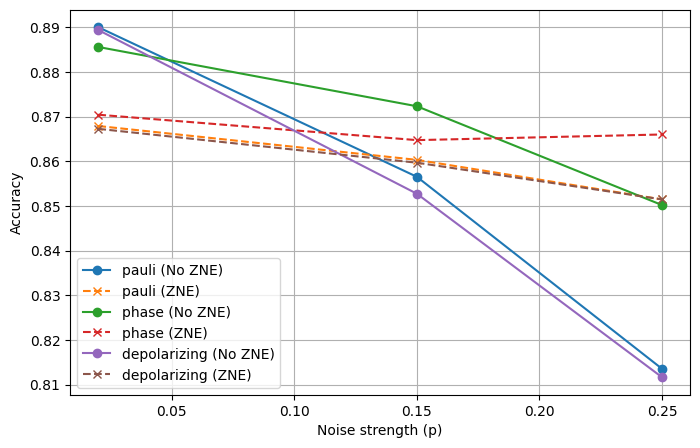

,noise_type,noise_strength,accuracy_no_zne,precision_no_zne,recall_no_zne,f1_no_zne,specificity_no_zne,roc_auc_no_zne,accuracy_zne,precision_zne,recall_zne,f1_zne,specificity_zne,roc_auc_zne,zne_gain
0,pauli,0.02,0.890013,0.900000,0.944751,0.921833,0.770161,0.937615,0.867889,0.893274,0.917127,0.905043,0.760081,0.920701,-0.022124
1,pauli,0.15,0.856511,0.869304,0.930939,0.899066,0.693548,0.882144,0.860303,0.872524,0.932781,0.901647,0.701613,0.906736,0.003793
2,pauli,0.25,0.813527,0.863177,0.865562,0.864368,0.699597,0.857107,0.851454,0.857864,0.939227,0.896703,0.659274,0.886711,0.037927
3,phase,0.02,0.885588,0.913242,0.920810,0.917011,0.808468,0.938564,0.870417,0.902283,0.909761,0.906006,0.784274,0.919518,-0.015171
4,phase,0.15,0.872314,0.931641,0.878453,0.904265,0.858871,0.936293,0.864728,0.901473,0.901473,0.901473,0.784274,0.921304,-0.007585


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# CONFIG 
SWEEP_NOISE_TYPES     = ["pauli", "phase", "depolarizing"]
SWEEP_NOISE_STRENGTHS = [0.02, 0.15, 0.25]
SWEEP_SEEDS           = [0]
EVAL_SHOTS = 1000

OUT_DIR = Path("quantum_sweep_results")
OUT_DIR.mkdir(exist_ok=True)

CSV_PATH  = OUT_DIR / "qtl_sweep_results.csv"
PLOT_PATH = OUT_DIR / "qtl_sweep_plot.png"


# METRICS
def compute_specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp = cm[0, 0], cm[0, 1]
    return tn / (tn + fp + 1e-8)


def evaluate_with_metrics(model, loader, device, zne=False):
    model.eval()
    logits_all, labels_all = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs, zne=zne)
            logits_all.append(outputs.cpu())
            labels_all.append(labels.cpu())

    logits = torch.cat(logits_all).numpy()
    y_true = torch.cat(labels_all).numpy()
    y_pred = np.argmax(logits, axis=1)
    probs  = torch.softmax(torch.tensor(logits), dim=1).numpy()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "specificity": compute_specificity(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, probs[:, 1])
    }


def run_sweep():
    rows = []

    for noise_type in SWEEP_NOISE_TYPES:
        for noise_strength in SWEEP_NOISE_STRENGTHS:
            for seed in SWEEP_SEEDS:

                print(f"Evaluating: noise={noise_type}, p={noise_strength}")
                set_seed(seed)

                # Load pretrained model 
                model = HQCNN_EfficientNet_Quantum_ZNE(
                    num_classes=NUM_CLASSES,
                    n_qubits=NUM_QUBITS,
                    n_layers=NUM_LAYERS,
                    freeze_backbone=True,
                    base_depol=noise_strength,
                    noise_type=noise_type,
                    use_shots=True
                ).to(DEVICE)

                model.load_state_dict(
                    torch.load("qtl_pretrained.pt", map_location=DEVICE)
                )

                model.quantum.shots = EVAL_SHOTS
                model.eval()

                # -------- Evaluate --------
                m_no_zne = evaluate_with_metrics(model, val_loader, DEVICE, zne=False)
                m_zne    = evaluate_with_metrics(model, val_loader, DEVICE, zne=True)

                rows.append({
                    "noise_type": noise_type,
                    "noise_strength": noise_strength,
                    **{f"{k}_no_zne": v for k, v in m_no_zne.items()},
                    **{f"{k}_zne": v for k, v in m_zne.items()},
                    "zne_gain": m_zne["accuracy"] - m_no_zne["accuracy"]
                })

    df = pd.DataFrame(rows)
    df.to_csv(CSV_PATH, index=False)
    print("Saved sweep results →", CSV_PATH)

    # Plot
    plt.figure(figsize=(8, 5))
    for noise in SWEEP_NOISE_TYPES:
        sub = df[df["noise_type"] == noise]
        plt.plot(sub["noise_strength"], sub["accuracy_no_zne"], "-o", label=f"{noise} (No ZNE)")
        plt.plot(sub["noise_strength"], sub["accuracy_zne"], "--x", label=f"{noise} (ZNE)")

    plt.xlabel("Noise strength (p)")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.savefig(PLOT_PATH, dpi=300)
    plt.show()

    return df


df_sweep = run_sweep()
df_sweep.head()
